# Comparison of Big model vs. Small
Does size metter?

In [15]:
%reload_ext autoreload
%autoreload 2

In [16]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.insert(0, module_path)
from plotting_utility import *

load performances

In [17]:
noise_module = [5, 10, 15, 20, 50]


In [18]:

tags = ["baseline", "JREG_0.1", "LIP_0.00001"]
load_benchmarks("ECON", tags, 1024, 0.0015625, noise_modules=noise_module)

In [19]:
tags = ["0.0", "GAUSSIAN_0.1", "GAUSSIAN_0.3", "GAUSSIAN_0.5", "GAUSSIAN_0.8", "SP_0.1", "SP_0.3", "SP_0.5", "SP_0.8"]
load_benchmarks("LARGE_ECON", tags, 1024, 0.0015625, noise_modules=noise_module)

In [20]:
df_injected = pd.read_csv("./results/LARGE_ECON/noise.csv")
df_reg = pd.read_csv("./results/ECON/noise.csv")

In [21]:
df_reg["regularizer"] = df_reg["regularizer"] + " (small)"
df_injected["regularizer"] = df_injected["regularizer"] + " (large)"

In [22]:
combined = pd.concat([df_injected, df_reg], ignore_index=True)
combined = combined[(combined['precision'].isin([4,5,6,7,8]))]

## Baseline

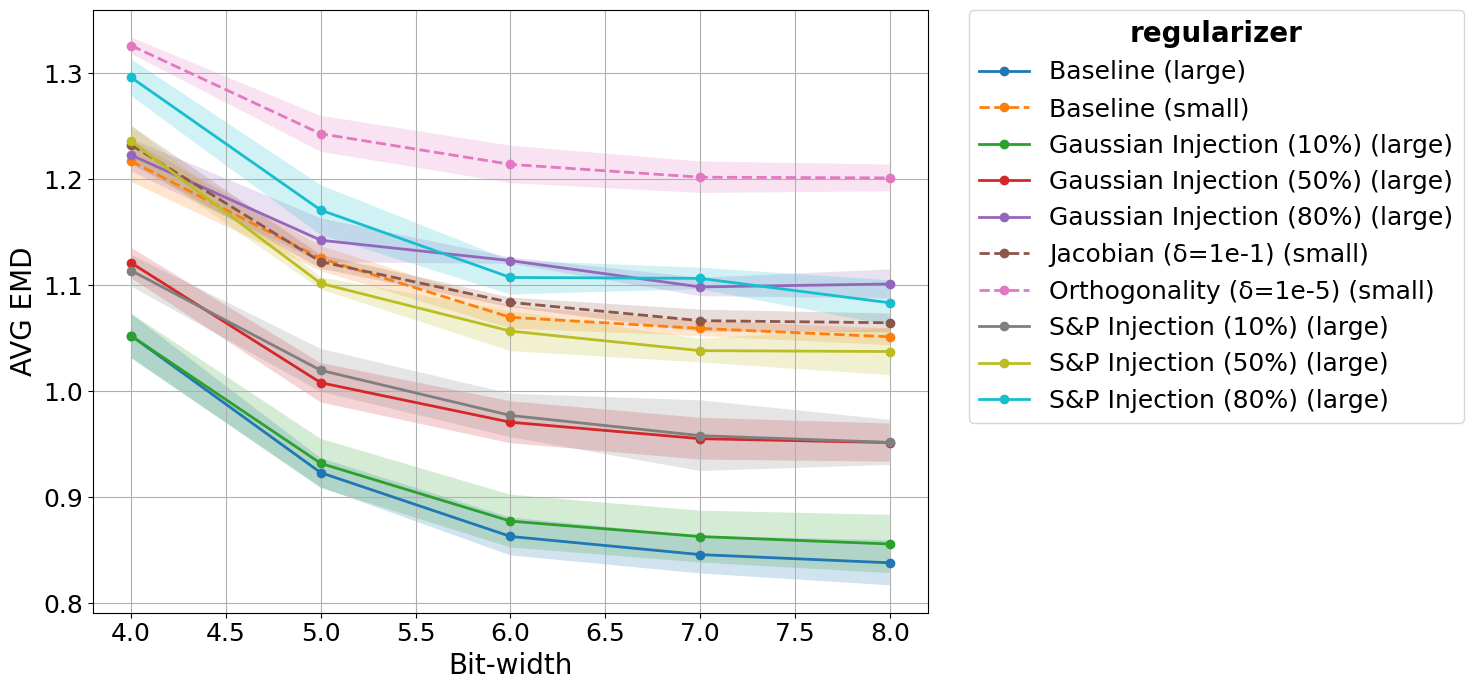

In [23]:
NOISE_TYPE = 'clean'
NOISE_MODULE = 0
regularizer = [
    "Baseline (small)", "Jacobian (δ=1e-1) (small)", "Orthogonality (δ=1e-5) (small)",
    "Baseline (large)", 
    "Gaussian Injection (10%) (large)",
    # "Gaussian Injection (30%) (large)",
    "Gaussian Injection (50%) (large)",
    "Gaussian Injection (80%) (large)",
    "Gaussian Injection (100%) (large)",
    "S&P Injection (10%) (large)",
    # "S&P Injection (30%) (large)",
    "S&P Injection (50%) (large)",
    "S&P Injection (80%) (large)",
    "S&P Injection (100%) (large)"
]
selected_df = combined[(combined['noise_type'] == "clean") & 
                 (combined['regularizer'].isin(regularizer))]
plot_precision_vs_performace(selected_df, "regularizer", std=True, plot_legend=True)

## Gaussian noise

--------------------------------------------------------------------------------
5


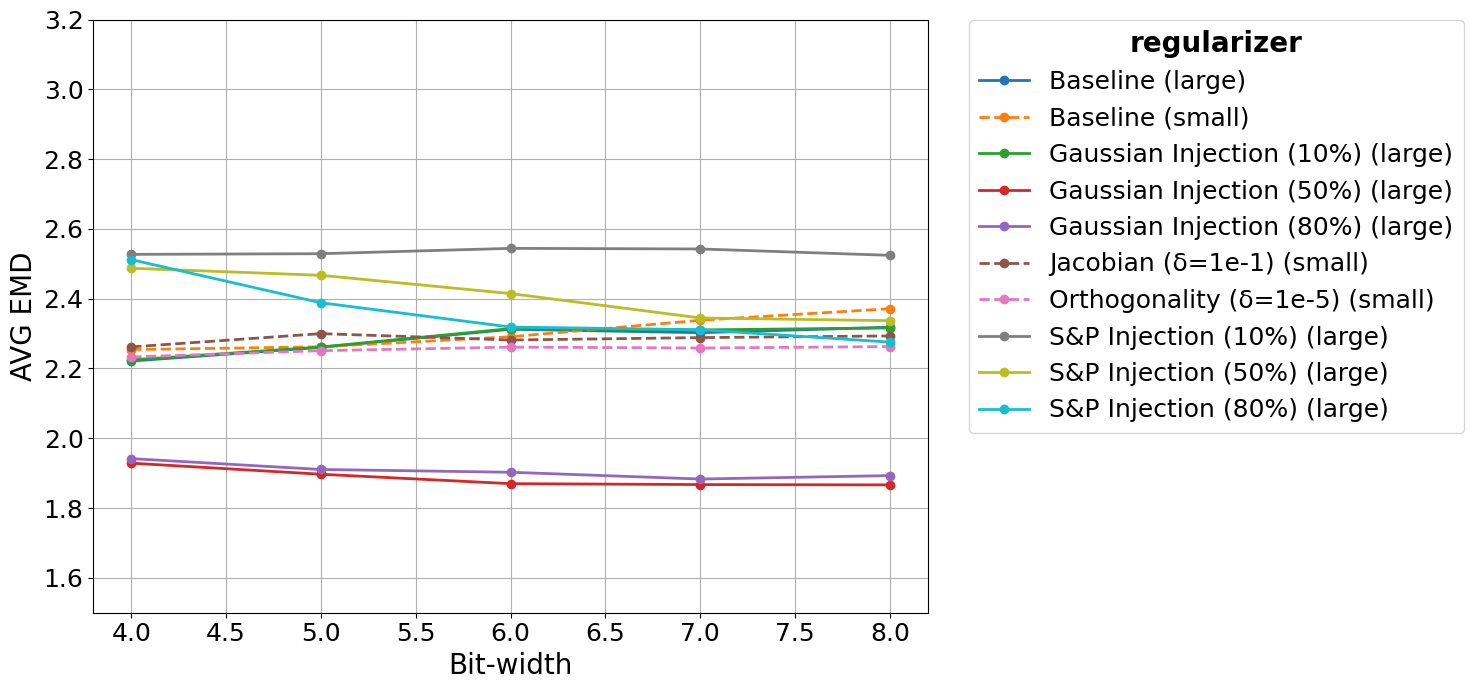

--------------------------------------------------------------------------------
10


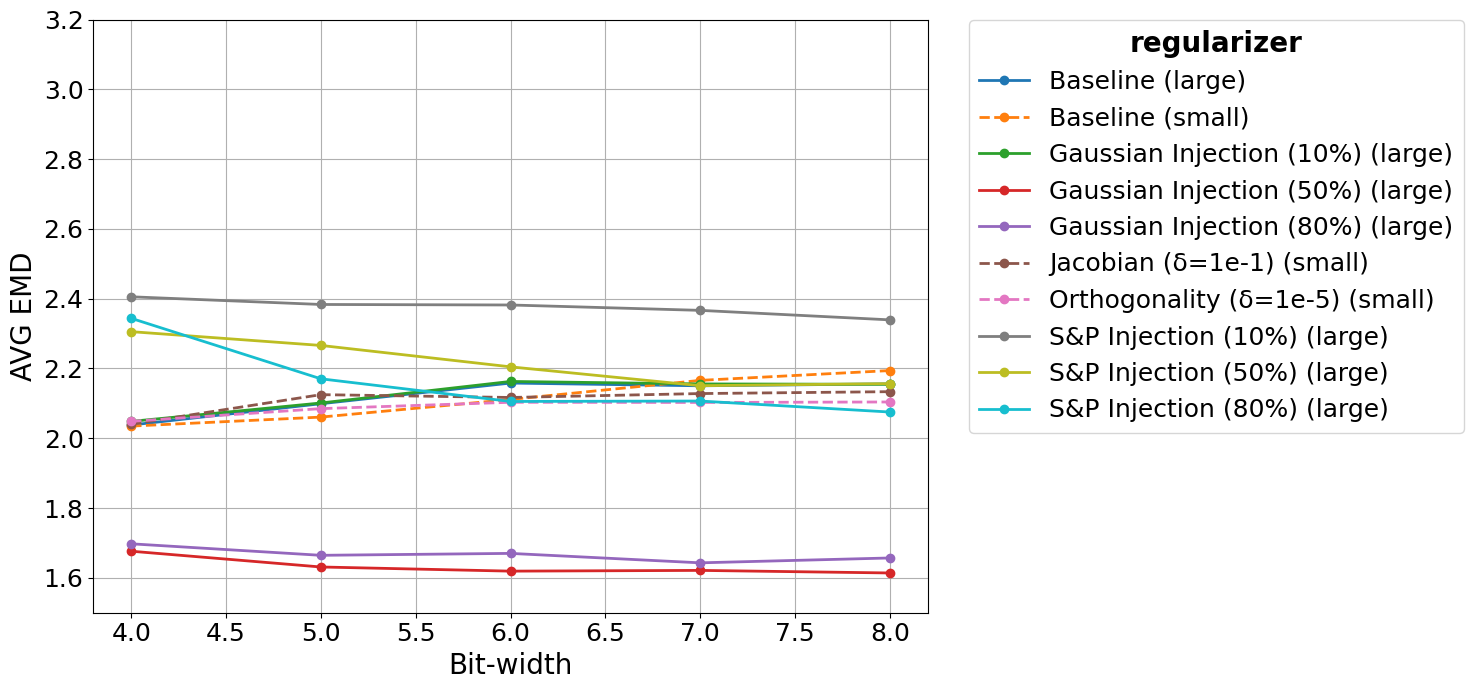

--------------------------------------------------------------------------------
20


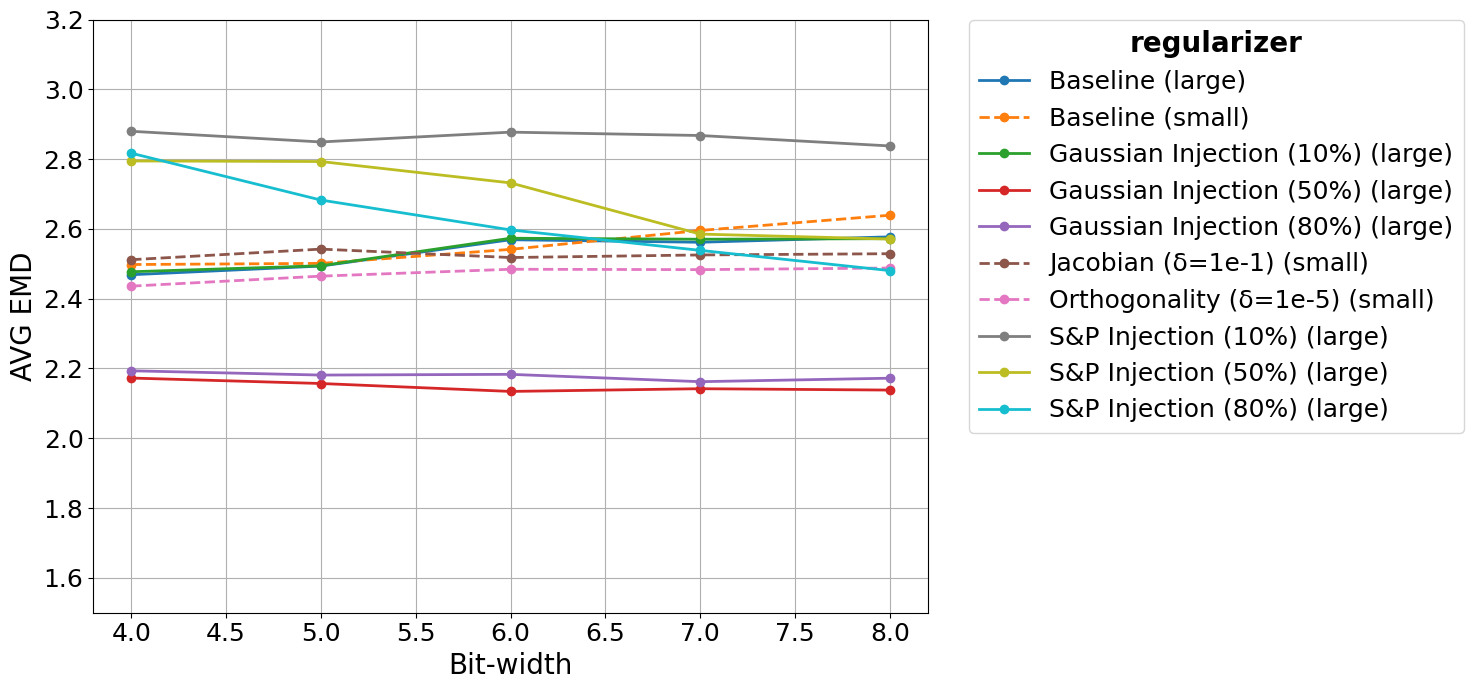

--------------------------------------------------------------------------------
50


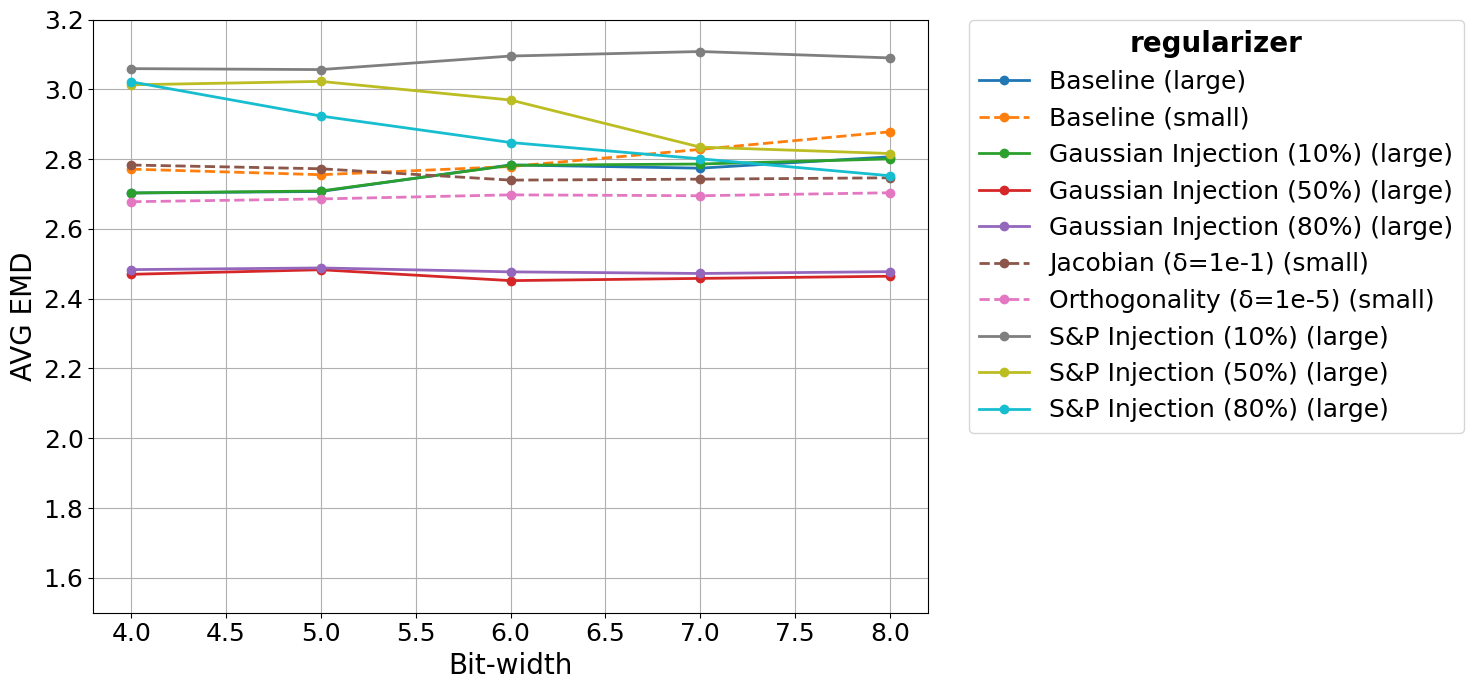

In [27]:
for module in [5, 10, 20, 50]:
    selected_df = combined[(combined['noise_type'] == "gaussian") & 
                    (combined['Noise module (%)'] == module) & 
                    (combined['regularizer'].isin(regularizer))]
    print(80*"-")
    print(module)
    plot_precision_vs_performace(selected_df, "regularizer", std=False, plot_legend=True, ylim=(1.5, 3.2))

## Salt & Pepper noise

--------------------------------------------------------------------------------
5


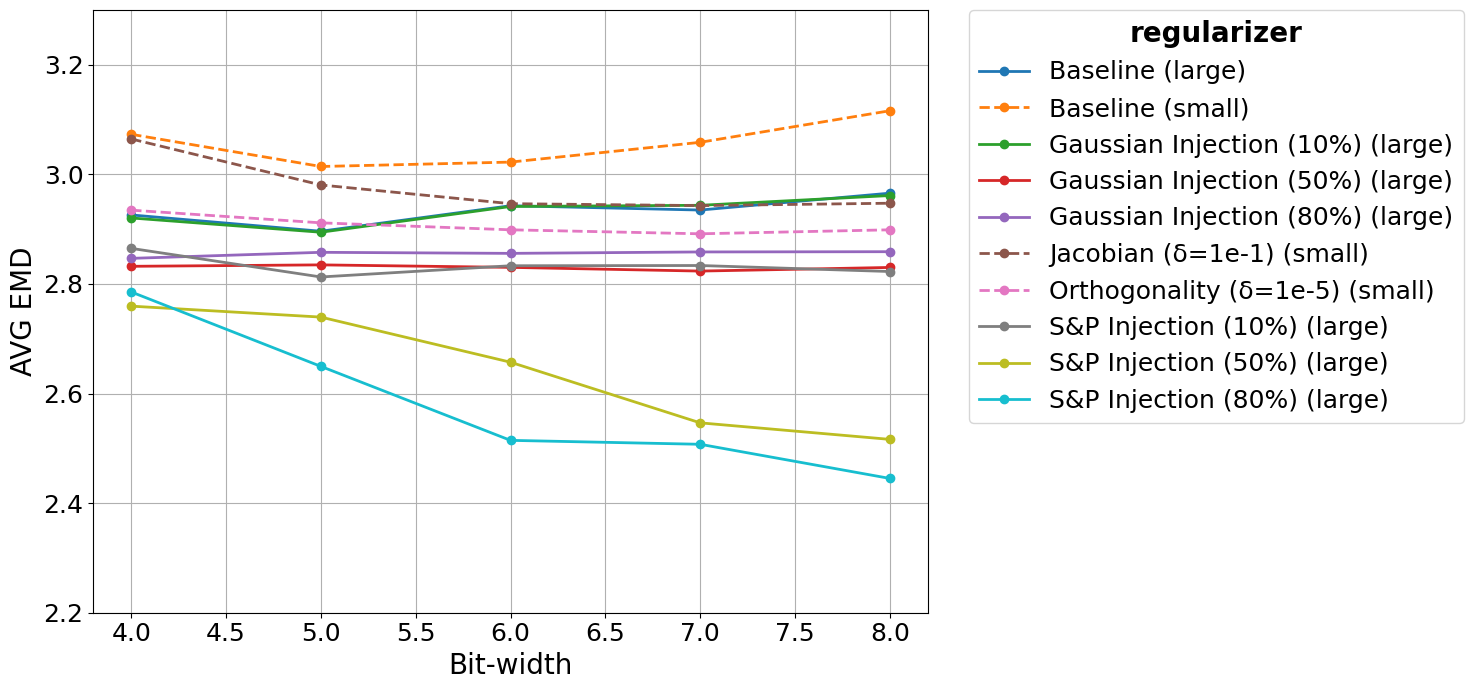

--------------------------------------------------------------------------------
10


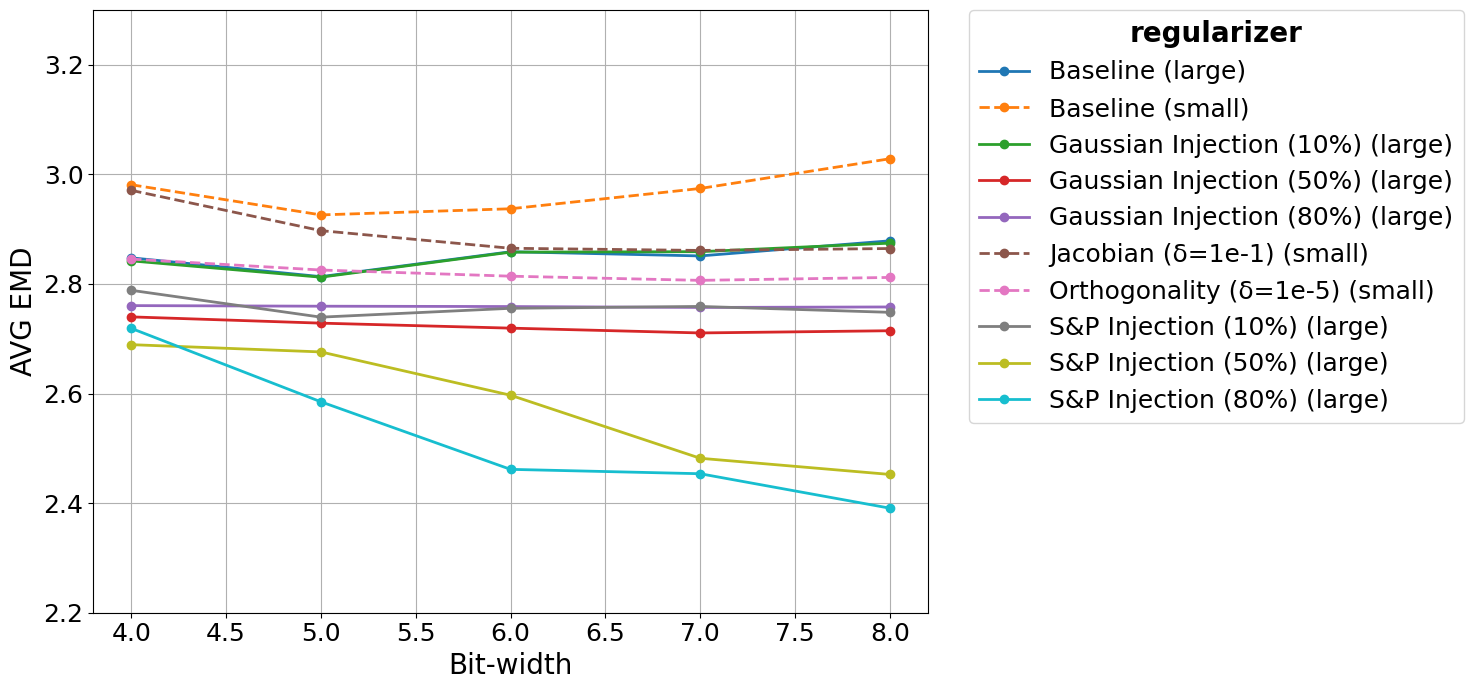

--------------------------------------------------------------------------------
20


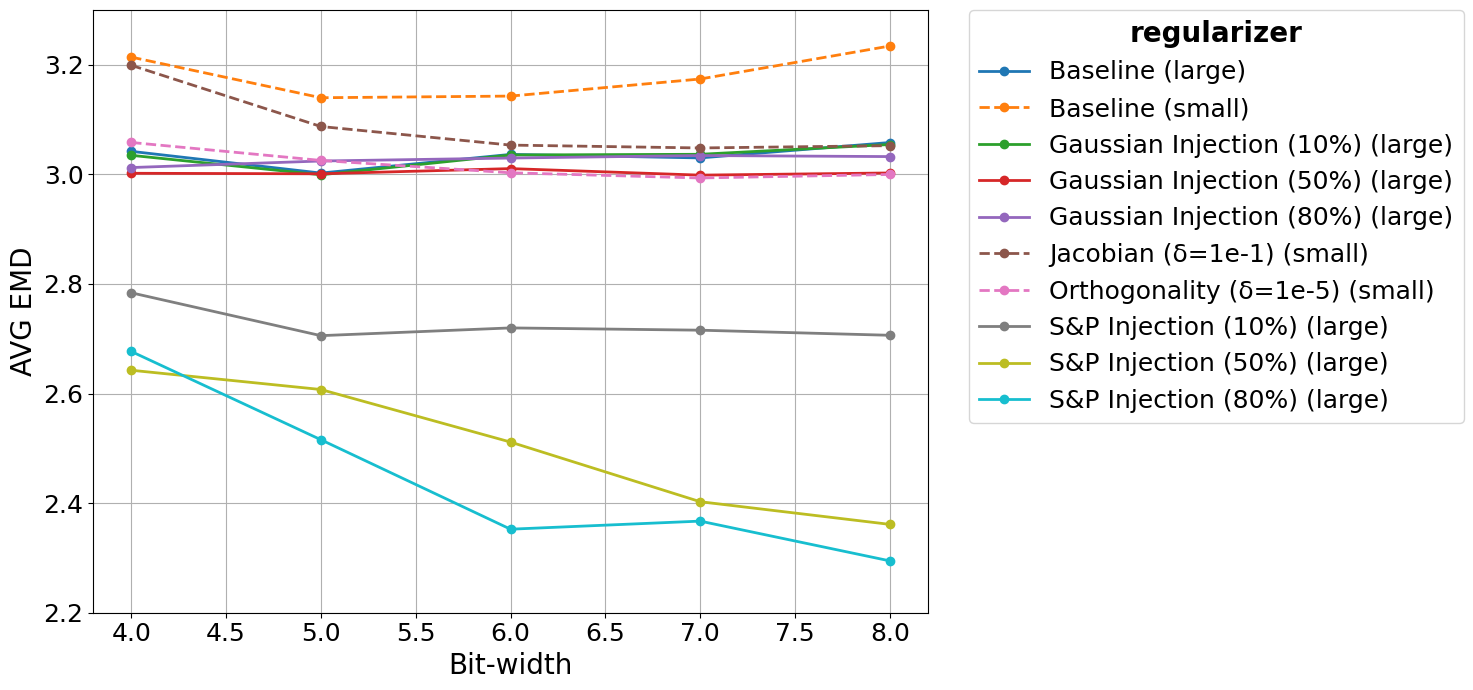

--------------------------------------------------------------------------------
50


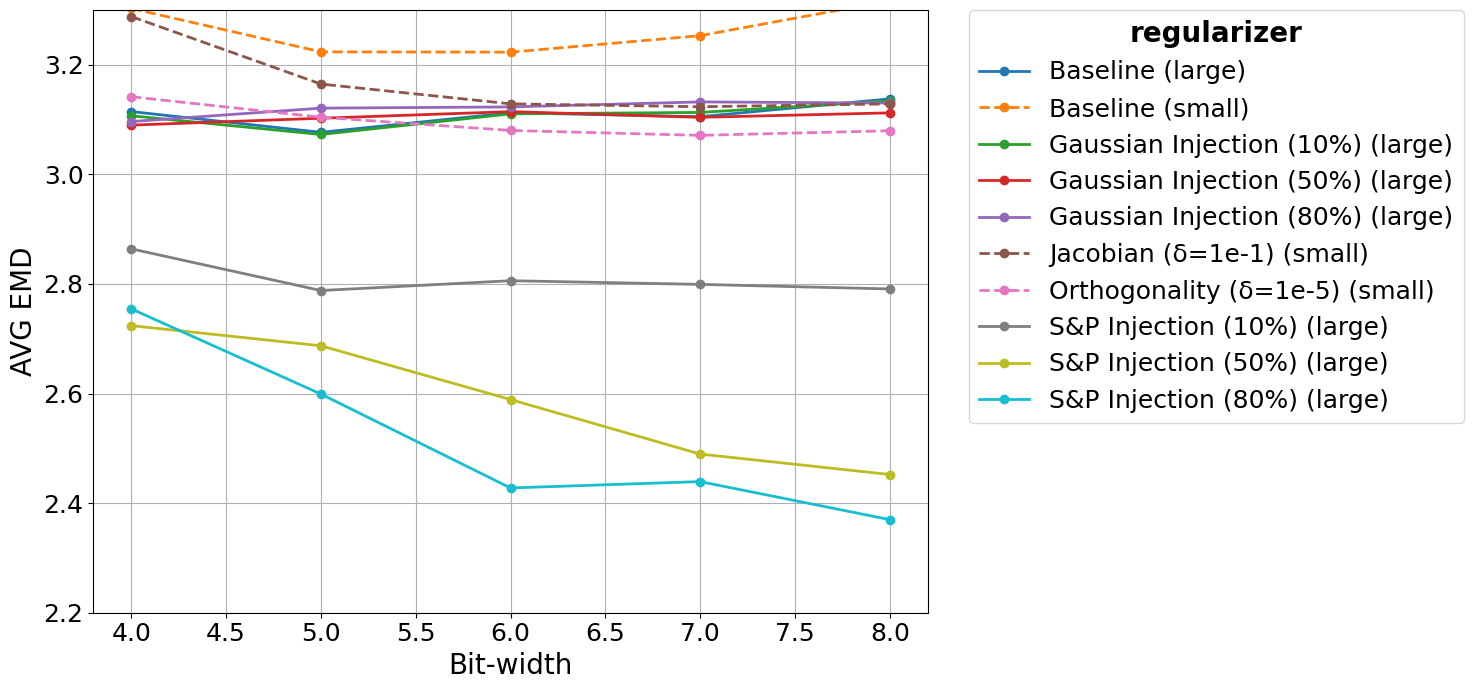

In [25]:
for module in [5, 10, 20, 50]:
    selected_df = combined[(combined['noise_type'] == "salt_pepper") & 
                    (combined['Noise module (%)'] == module) & 
                    (combined['regularizer'].isin(regularizer))]
    print(80*"-")
    print(module)
    plot_precision_vs_performace(selected_df, "regularizer", std=False, plot_legend=True, ylim=(2.2, 3.3))